In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols]
y_test_pca = test_df_pca["target"]

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [6]:
#First train with the ANOVA-10 features

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

dt_preds = dt.predict(x_test)
dt_accuracy = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", dt_accuracy)
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.91      0.82      0.87        74
           1       0.82      0.89      0.85        72
           2       0.83      0.84      0.83        74

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.85       220
weighted avg       0.85      0.85      0.85       220



In [8]:
#Try with PCA features

In [9]:
dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(x_train_pca, y_train_pca)

dt_preds_pca = dt_pca.predict(x_test_pca)
dt_accuracy_pca = accuracy_score(y_test_pca, dt_preds_pca)

print("Decision Tree Accuracy (PCA):", dt_accuracy_pca)
print(classification_report(y_test_pca, dt_preds_pca))

Decision Tree Accuracy (PCA): 0.8772727272727273
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        74
           1       0.85      0.89      0.87        72
           2       0.91      0.86      0.89        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [ ]:
#Compare the two accuracies and pick the better feature set PCA
#Moving to hyperparameter tuning for PCA

In [11]:
from sklearn.model_selection import GridSearchCV

In [12]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(x_train_pca, y_train_pca)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'ccp_alpha': [0.0, 0.001, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [13]:
best_dt = grid_dt.best_estimator_

print("Best DT parameters:", grid_dt.best_params_)
print("Best DT CV accuracy:", grid_dt.best_score_)

Best DT parameters: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best DT CV accuracy: 0.8875


In [14]:
tuned_dt_preds = best_dt.predict(x_test_pca)
tuned_dt_accuracy = accuracy_score(y_test_pca, tuned_dt_preds)

print("Tuned DT Test Accuracy:", tuned_dt_accuracy)
print(classification_report(y_test_pca, tuned_dt_preds))

Tuned DT Test Accuracy: 0.8818181818181818
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        74
           1       0.84      0.93      0.88        72
           2       0.95      0.81      0.88        74

    accuracy                           0.88       220
   macro avg       0.89      0.88      0.88       220
weighted avg       0.89      0.88      0.88       220



In [15]:
tuned_dt_preds_train = best_dt.predict(x_train_pca)
print("Tuned DT Train Accuracy:", accuracy_score(y_train_pca, tuned_dt_preds_train))

Tuned DT Train Accuracy: 0.9147727272727273


In [16]:
import joblib
joblib.dump(best_dt, "../results/model_trained_files/decision_tree_model.pkl")

['../results/model_trained_files/decision_tree_model.pkl']

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

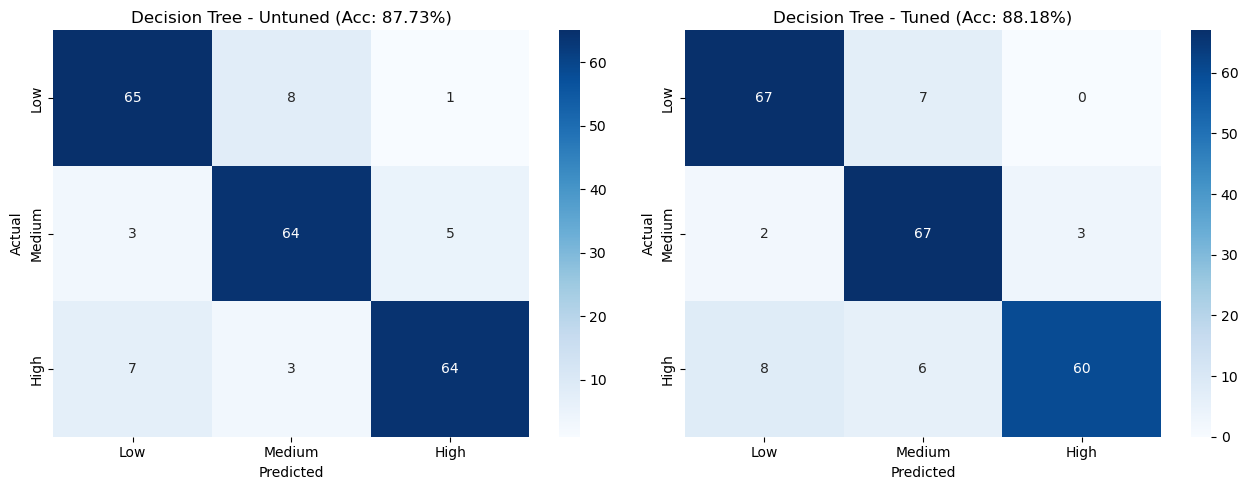

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test_pca, tuned_dt_preds)

cm_unt = confusion_matrix(y_test_pca, dt_preds_pca)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"Decision Tree - Untuned (Acc: {dt_accuracy_pca:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"Decision Tree - Tuned (Acc: {tuned_dt_accuracy:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/dt_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()